### MCPhases Exploratory Data Analysis Notebook
===========================================

This notebook helps you visualize and understand the mcphases dataset
before building predictive models.

Run each section to explore your data!

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [ ]:
# ============================================================================
# SECTION 1: LOAD AND OVERVIEW
# ============================================================================

print("="*70)
print("MCPHASES EXPLORATORY DATA ANALYSIS")
print("="*70)

# Load main table
DATA_PATH = r"D:\MajorProject\mcphases"  # UPDATE THIS
hormones = pd.read_csv(r"D:\MajorProject\EDA\hormones_selfrep.csv")

print(f"\n📊 Dataset Overview:")
print(f"  Total records: {len(hormones):,}")
print(f"  Unique participants: {hormones['id'].nunique()}")
print(f"  Date range: Day 1 to Day {hormones['day_in_study'].max()}")
print(f"  Study intervals: {hormones['study_interval'].unique()}")

print(f"\n📋 Available Data:")
print(f"  Hormone measurements: {(~hormones['lh'].isna()).sum():,} LH readings")
print(f"  Flow tracking: {(hormones['flow_volume_imputed'] > 0).sum():,} menstruation days")
print(f"  Symptom reports: {(~hormones['cramps'].isna()).sum():,} daily entries")

MCPHASES EXPLORATORY DATA ANALYSIS

📊 Dataset Overview:
  Total records: 5,659
  Unique participants: 42
  Date range: Day 1 to Day 1004
  Study intervals: [2022 2024]

📋 Available Data:
  Hormone measurements: 5,339 LH readings
  Flow tracking: 1,120 menstruation days
  Symptom reports: 3,032 daily entries


In [4]:
hormones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5659 entries, 0 to 5658
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5659 non-null   int64  
 1   study_interval       5659 non-null   int64  
 2   is_weekend           5659 non-null   bool   
 3   day_in_study         5659 non-null   int64  
 4   phase                5659 non-null   object 
 5   lh                   5339 non-null   float64
 6   estrogen             5338 non-null   float64
 7   pdg                  1864 non-null   float64
 8   flow_volume          3189 non-null   object 
 9   flow_color           3194 non-null   object 
 10  appetite             2421 non-null   float64
 11  exerciselevel        1504 non-null   float64
 12  headaches            2824 non-null   float64
 13  cramps               3032 non-null   float64
 14  sorebreasts          2977 non-null   float64
 15  fatigue              2779 non-null   f


VISUALIZING ONE PARTICIPANT'S CYCLE

Analyzing participant: 26
Days tracked: 210

✓ Saved: participant_cycle_visualization.png


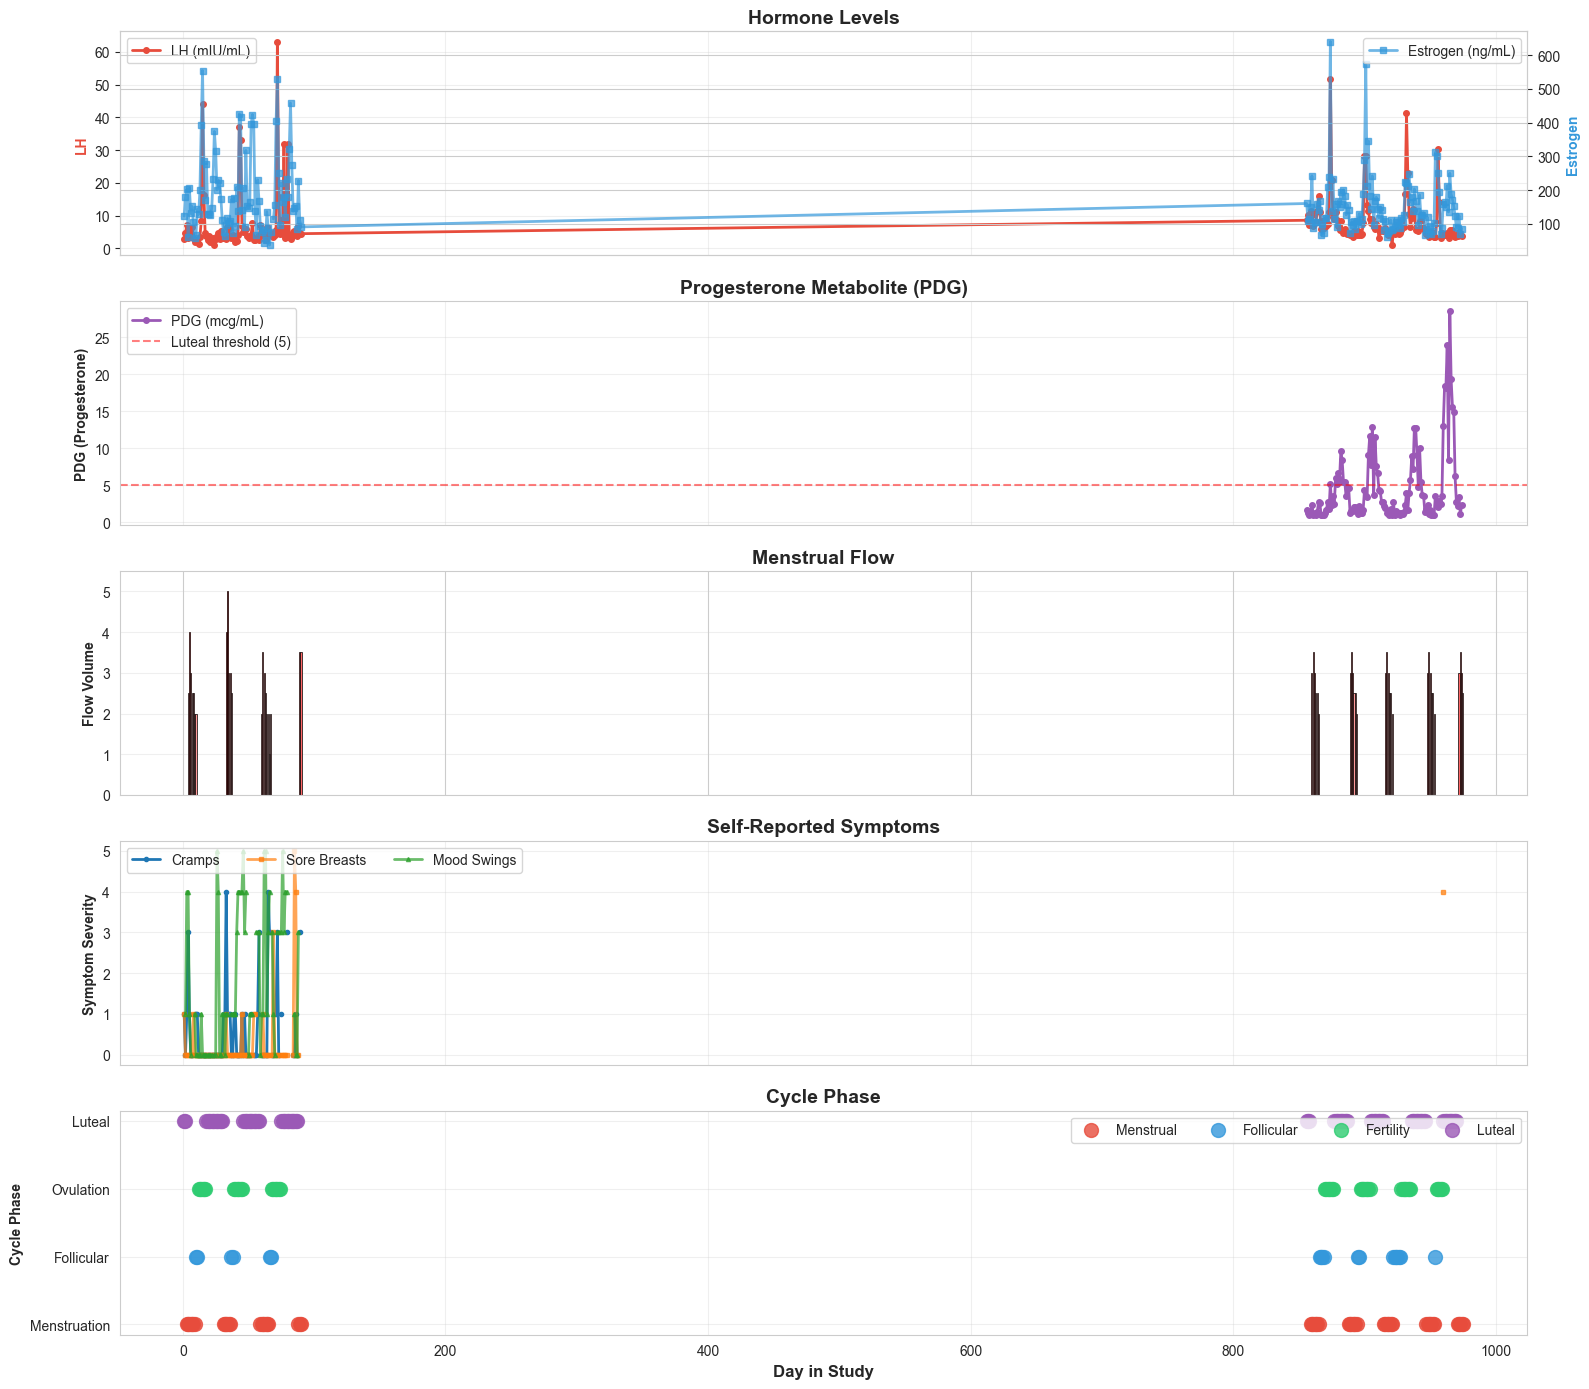

In [5]:
# ============================================================================
# SECTION 2: SINGLE PARTICIPANT DEEP DIVE
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING ONE PARTICIPANT'S CYCLE")
print("="*70)

# Pick a participant with good data coverage
participant_id = hormones.groupby('id').size().idxmax()  # Most data points
p_data = hormones[hormones['id'] == participant_id].sort_values('day_in_study')

print(f"\nAnalyzing participant: {participant_id}")
print(f"Days tracked: {len(p_data)}")

# Create comprehensive visualization
fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

# Plot 1: Hormones
ax1 = axes[0]
ax1.plot(p_data['day_in_study'], p_data['lh'], 'o-', label='LH (mIU/mL)', 
         color='#e74c3c', linewidth=2, markersize=4)
ax1_twin = ax1.twinx()
ax1_twin.plot(p_data['day_in_study'], p_data['estrogen'], 's-', label='Estrogen (ng/mL)', 
              color='#3498db', linewidth=2, markersize=4, alpha=0.7)
ax1.set_ylabel('LH', color='#e74c3c', fontweight='bold')
ax1_twin.set_ylabel('Estrogen', color='#3498db', fontweight='bold')
ax1.set_title('Hormone Levels', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Progesterone (PDG)
ax2 = axes[1]
ax2.plot(p_data['day_in_study'], p_data['pdg'], 'o-', label='PDG (mcg/mL)', 
         color='#9b59b6', linewidth=2, markersize=4)
ax2.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Luteal threshold (5)')
ax2.set_ylabel('PDG (Progesterone)', fontweight='bold')
ax2.set_title('Progesterone Metabolite (PDG)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Menstrual Flow
ax3 = axes[2]
flow_colors = {0: 'white', 1: '#ffcccb', 2: '#ff9999', 3: '#ff6666', 4: '#ff3333', 5: '#cc0000'}
colors = [flow_colors.get(int(v), 'gray') for v in p_data['flow_volume_imputed'].fillna(0)]
ax3.bar(p_data['day_in_study'], p_data['flow_volume_imputed'].fillna(0), 
        color=colors, edgecolor='black', linewidth=0.5)
ax3.set_ylabel('Flow Volume', fontweight='bold')
ax3.set_title('Menstrual Flow', fontsize=14, fontweight='bold')
ax3.set_ylim(0, 5.5)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Symptoms
ax4 = axes[3]
ax4.plot(p_data['day_in_study'], p_data['cramps'], 'o-', label='Cramps', 
         linewidth=2, markersize=3)
ax4.plot(p_data['day_in_study'], p_data['sorebreasts'], 's-', label='Sore Breasts', 
         linewidth=2, markersize=3, alpha=0.7)
ax4.plot(p_data['day_in_study'], p_data['moodswing'], '^-', label='Mood Swings', 
         linewidth=2, markersize=3, alpha=0.7)
ax4.set_ylabel('Symptom Severity', fontweight='bold')
ax4.set_title('Self-Reported Symptoms', fontsize=14, fontweight='bold')
ax4.legend(loc='upper left', ncol=3)
ax4.grid(True, alpha=0.3)

# Plot 5: Phase Labels
ax5 = axes[4]
if 'phase' in p_data.columns and p_data['phase'].notna().any():
    phase_map = {'Follicular': 1, 'Fertility': 2, 'Luteal': 3, 'Menstrual': 0}
    phase_colors = {'Menstrual': '#e74c3c', 'Follicular': '#3498db', 
                   'Fertility': '#2ecc71', 'Luteal': '#9b59b6'}
    
    for phase, color in phase_colors.items():
        phase_days = p_data[p_data['phase'] == phase]
        if len(phase_days) > 0:
            ax5.scatter(phase_days['day_in_study'], 
                       [phase_map[phase]] * len(phase_days),
                       s=100, c=color, label=phase.capitalize(), alpha=0.8)
    
    ax5.set_ylabel('Cycle Phase', fontweight='bold')
    ax5.set_yticks([0, 1, 2, 3])
    ax5.set_yticklabels(['Menstruation', 'Follicular', 'Ovulation', 'Luteal'])
    ax5.legend(loc='upper right', ncol=4)
else:
    ax5.text(0.5, 0.5, 'No phase labels available', 
            transform=ax5.transAxes, ha='center', va='center', fontsize=12)

ax5.set_xlabel('Day in Study', fontsize=12, fontweight='bold')
ax5.set_title('Cycle Phase', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('participant_cycle_visualization.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: participant_cycle_visualization.png")

#### flow volume is marked as 0 in most of the cases it needs to be filled before anything can be said 


📊 Cycle Statistics:
  Participants with ≥2 cycles: 38
  Regular cycles: 34 (89.5%)
  Average cycle length: 29.9 ± 2.9 days
  Range: 23 - 36 days

✓ Saved: cycle_analysis.png


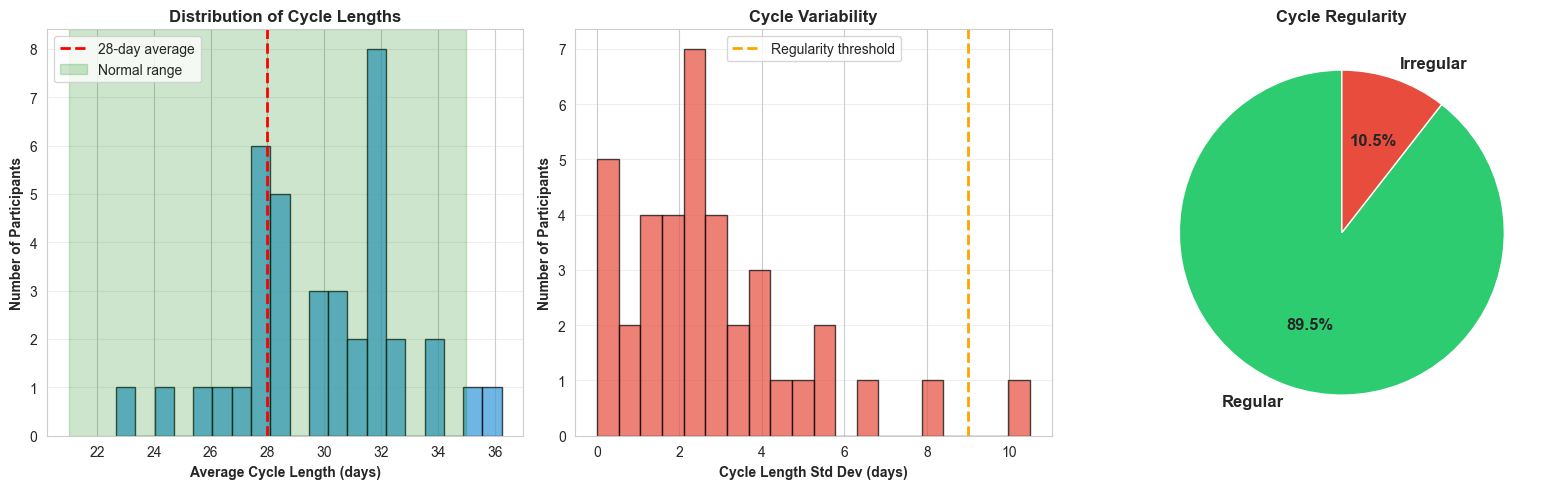

In [6]:
def detect_cycles(hormones):
    """Detect cycle starts using phase transitions instead of flow volume"""
    hormones = hormones.sort_values('day_in_study').reset_index(drop=True)
    
    cycle_starts = []
    
    for i in range(len(hormones)):
        current_phase = hormones.loc[i, 'phase']
        prev_phase = hormones.loc[i-1, 'phase'] if i > 0 else None
        
        # Cycle starts when phase transitions INTO Menstrual
        if current_phase == 'Menstrual' and prev_phase != 'Menstrual':
            cycle_starts.append(hormones.loc[i, 'day_in_study'])
    
    if len(cycle_starts) < 3:
        return [], None, None
    
    cycle_lengths = np.diff(cycle_starts)
    
    # Filter out physiologically impossible cycle lengths
    cycle_lengths = cycle_lengths[
        (cycle_lengths >= 15) & (cycle_lengths <= 60)
    ]
    
    if len(cycle_lengths) == 0:
        return cycle_starts, None, None
    
    return cycle_starts, cycle_lengths, np.mean(cycle_lengths)


# Analyze all participants
cycle_analysis = []
for pid in hormones['id'].unique():
    p_data = hormones[hormones['id'] == pid]
    starts, lengths, avg_length = detect_cycles(p_data)
    
    if lengths is not None and len(lengths) > 0:
        is_regular = (21 <= avg_length <= 35) and (np.std(lengths) < 7)
        cycle_analysis.append({
            'id': pid,
            'num_cycles': len(lengths),
            'avg_length': avg_length,
            'std_length': np.std(lengths),
            'min_length': np.min(lengths),
            'max_length': np.max(lengths),
            'is_regular': is_regular
        })

cycle_df = pd.DataFrame(cycle_analysis)

if len(cycle_df) > 0:
    print(f"\n📊 Cycle Statistics:")
    print(f"  Participants with ≥2 cycles: {len(cycle_df)}")
    print(f"  Regular cycles: {cycle_df['is_regular'].sum()} ({cycle_df['is_regular'].mean()*100:.1f}%)")
    print(f"  Average cycle length: {cycle_df['avg_length'].mean():.1f} ± {cycle_df['avg_length'].std():.1f} days")
    print(f"  Range: {cycle_df['avg_length'].min():.0f} - {cycle_df['avg_length'].max():.0f} days")
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    axes[0].hist(cycle_df['avg_length'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].axvline(28, color='red', linestyle='--', linewidth=2, label='28-day average')
    axes[0].axvspan(21, 35, alpha=0.2, color='green', label='Normal range')
    axes[0].set_xlabel('Average Cycle Length (days)', fontweight='bold')
    axes[0].set_ylabel('Number of Participants', fontweight='bold')
    axes[0].set_title('Distribution of Cycle Lengths', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    axes[1].hist(cycle_df['std_length'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.7)
    axes[1].axvline(9, color='orange', linestyle='--', linewidth=2, label='Regularity threshold')
    axes[1].set_xlabel('Cycle Length Std Dev (days)', fontweight='bold')
    axes[1].set_ylabel('Number of Participants', fontweight='bold')
    axes[1].set_title('Cycle Variability', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    regularity_counts = cycle_df['is_regular'].value_counts()
    labels = ['Regular' if x else 'Irregular' for x in regularity_counts.index]
    axes[2].pie(regularity_counts, labels=labels, autopct='%1.1f%%',
               colors=['#2ecc71' if x else '#e74c3c' for x in regularity_counts.index],
               startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
    axes[2].set_title('Cycle Regularity', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('cycle_analysis.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: cycle_analysis.png")

In [7]:
# Check PDG distribution in Menstrual phase
menstrual_pdg = hormones[
    hormones['phase'] == 'Menstrual'
]['pdg']

print("Original (non-imputed) PDG in Menstrual phase:")
print(menstrual_pdg.describe())
print(f"Values above threshold (5): {(menstrual_pdg > 5).sum()}")
print(f"Total non-null Menstrual PDG rows: {menstrual_pdg.notna().sum()}")

# Are high Menstrual PDG values from original data or imputed?
menstrual_rows = hormones[hormones['phase'] == 'Menstrual']
high_pdg_menstrual = menstrual_rows[menstrual_rows['pdg'] > 5]
print(f"\nHigh PDG (>5) Menstrual rows: {len(high_pdg_menstrual)}")
print(high_pdg_menstrual[['id', 'day_in_study', 'pdg', 'pdg_imputed', 'lh']].head(10))

Original (non-imputed) PDG in Menstrual phase:
count    360.000000
mean       3.499722
std        3.883366
min        1.000000
25%        1.200000
50%        2.100000
75%        4.100000
max       26.400000
Name: pdg, dtype: float64
Values above threshold (5): 73
Total non-null Menstrual PDG rows: 360

High PDG (>5) Menstrual rows: 73
     id  day_in_study   pdg  pdg_imputed    lh
753   9           938   7.4          7.4   3.8
755   9           940   9.3          9.3  15.3
782   9           967   6.3          6.3   2.3
783   9           968   7.3          7.3   6.3
784   9           969   6.1          6.1   5.6
785   9           970  10.4         10.4   9.0
917  10           913   5.2          5.2   6.8
918  10           914   7.2          7.2   8.9
919  10           915  13.1         13.1   7.4
920  10           916  25.4         25.4  18.1


In [8]:
# Check estrogen distribution in Luteal vs Fertility
print("Estrogen by phase - full distribution:")
print(hormones.groupby('phase')['estrogen'].describe().round(2))

# Check how many non-null estrogen values exist per phase
print("\nNon-null estrogen counts by phase:")
print(hormones.groupby('phase')['estrogen'].count())

# Check if high Luteal estrogen is driven by few users
print("\nPer-user median estrogen in Luteal phase:")
print(hormones[hormones['phase'] == 'Luteal']
      .groupby('id')['estrogen']
      .median()
      .sort_values(ascending=False)
      .head(10))

Estrogen by phase - full distribution:
             count    mean     std  min    25%     50%     75%    max
phase                                                                
Fertility   1217.0  173.08  131.91  0.0  84.70  133.70  213.50  640.0
Follicular  1313.0  101.68   72.84  0.0  58.00   83.10  126.50  640.0
Luteal      1790.0  139.69  100.96  4.0  75.60  113.55  169.98  640.0
Menstrual   1018.0   92.68   63.67  0.0  51.72   77.15  115.62  640.0

Non-null estrogen counts by phase:
phase
Fertility     1217
Follicular    1313
Luteal        1790
Menstrual     1018
Name: estrogen, dtype: int64

Per-user median estrogen in Luteal phase:
id
39    515.30
18    273.35
37    242.25
11    210.70
49    205.20
45    191.25
34    190.05
23    182.20
40    182.00
8     160.30
Name: estrogen, dtype: float64


In [9]:
# How many users have abnormally high Luteal estrogen (>300)
high_estrogen_users = (
    hormones[hormones['phase'] == 'Luteal']
    .groupby('id')['estrogen']
    .median()
)

print("Users with Luteal estrogen > 300:")
print(high_estrogen_users[high_estrogen_users > 300])

print("\nUsers with Luteal estrogen > 200:")
print(high_estrogen_users[high_estrogen_users > 200])

# Check if these same users also have high Fertility estrogen
# or if it's specifically elevated in Luteal only
problem_users = high_estrogen_users[high_estrogen_users > 200].index.tolist()

print("\nEstrogen by phase for high-Luteal users:")
print(
    hormones[hormones['id'].isin(problem_users)]
    .groupby(['id', 'phase'])['estrogen']
    .median()
    .unstack()
    .round(2)
)

Users with Luteal estrogen > 300:
id
39    515.3
Name: estrogen, dtype: float64

Users with Luteal estrogen > 200:
id
11    210.70
18    273.35
37    242.25
39    515.30
49    205.20
Name: estrogen, dtype: float64

Estrogen by phase for high-Luteal users:
phase  Fertility  Follicular  Luteal  Menstrual
id                                             
11        168.65       80.80  210.70      90.10
18        282.05      209.35  273.35     181.35
37        178.90      166.50  242.25     187.60
39        327.65      160.90  515.30     210.70
49        380.10       96.40  205.20      77.20


In [10]:
# 640 appears as max in every phase — suspicious, could be a cap/sensor limit
print("How many rows have estrogen == 640?")
print((hormones['estrogen'] == 640).sum())

print("\nBy phase:")
print(hormones[hormones['estrogen'] == 640]
      ['phase'].value_counts())

print("\nWhich users have estrogen == 640?")
print(hormones[hormones['estrogen'] == 640]
      ['id'].value_counts())

How many rows have estrogen == 640?
50

By phase:
phase
Fertility     29
Luteal        15
Follicular     4
Menstrual      2
Name: count, dtype: int64

Which users have estrogen == 640?
id
39    16
18    13
15     6
34     2
45     2
14     2
11     1
20     1
3      1
4      1
26     1
23     1
41     1
48     1
49     1
Name: count, dtype: int64


In [11]:
# Step 1: Flag sensor cap values
hormones['estrogen_capped_flag'] = (
    hormones['estrogen'] == 640
)
print(f"Flagged {hormones['estrogen_capped_flag'].sum()} sensor cap rows")

# Step 2: Replace 640 with NaN — treat as missing since true value is unknown
hormones['estrogen_clean'] = hormones['estrogen'].replace(640, np.nan)

# Step 3: For user 39 specifically — check if they're a genuine outlier
# or should be excluded from population analysis
user39_stats = hormones[hormones['id'] == 39]['estrogen_clean'].describe()
print(f"\nUser 39 estrogen (excluding 640 cap values):")
print(user39_stats)

# Check what normal population looks like without user 39 and without 640 values
normal_pop = hormones[
    (hormones['id'] != 39) & 
    (hormones['estrogen'] != 640)
]

print("\nEstrogen by phase AFTER removing caps and user 39:")
print(normal_pop.groupby('phase')['estrogen_clean']
      .median()
      .round(2))

Flagged 50 sensor cap rows

User 39 estrogen (excluding 640 cap values):
count     73.000000
mean     259.461644
std      145.054922
min       87.000000
25%      150.700000
50%      210.700000
75%      344.000000
max      637.800000
Name: estrogen_clean, dtype: float64

Estrogen by phase AFTER removing caps and user 39:
phase
Fertility     130.0
Follicular     80.9
Luteal        111.9
Menstrual      76.6
Name: estrogen_clean, dtype: float64


In [12]:
# Impute estrogen_clean using phase-based median
# (only ~5.7% missing originally + 50 cap values = still very manageable)

phase_estrogen_median = (
    hormones[hormones['estrogen_clean'].notna()]
    .groupby('phase')['estrogen_clean']
    .median()
)

user_estrogen_median = (
    hormones[hormones['estrogen_clean'].notna()]
    .groupby('id')['estrogen_clean']
    .median()
)

def impute_estrogen(row):
    if pd.notna(row['estrogen_clean']):
        return row['estrogen_clean']
    # Use user's own median first, fall back to phase median
    u_median = user_estrogen_median.get(row['id'], None)
    return u_median if pd.notna(u_median) else phase_estrogen_median[row['phase']]

hormones['estrogen_imputed'] = hormones.apply(
    impute_estrogen, axis=1
)

print("\nFinal estrogen imputed median by phase:")
print(hormones.groupby('phase')['estrogen_imputed'].median().round(2))


Final estrogen imputed median by phase:
phase
Fertility     128.70
Follicular     85.55
Luteal        111.65
Menstrual      79.00
Name: estrogen_imputed, dtype: float64


In [13]:
# Option A: Keep user 39 but flag them
hormones['high_estrogen_flag'] = (
    hormones['id'] == 39
)

# # Option B: Exclude user 39 from population analysis entirely
# hormones_clean = hormones[hormones['id'] != 39].copy()
# print(f"Rows after excluding user 39: {len(hormones_clean)}")

In [14]:
print("LH by phase full distribution:")
print(hormones.groupby('phase')['lh'].describe().round(2))

# Check if LH has same 640 cap issue
print(f"\nLH == max value rows: {(hormones['lh'] == hormones['lh'].max()).sum()}")
print(f"LH max value: {hormones['lh'].max()}")

# Check Menstrual LH specifically
print("\nMenstrual LH distribution:")
print(hormones[hormones['phase'] == 'Menstrual']['lh'].describe())

LH by phase full distribution:
             count   mean    std  min  25%   50%   75%    max
phase                                                        
Fertility   1217.0  11.16  13.80  0.0  3.7  6.20  12.2  185.6
Follicular  1314.0   5.65   4.29  0.0  3.0  4.65   7.1   54.0
Luteal      1790.0   4.51   3.92  1.0  2.5  3.80   5.4   68.0
Menstrual   1018.0   4.66   3.31  0.0  2.7  4.10   5.8   53.6

LH == max value rows: 1
LH max value: 185.6

Menstrual LH distribution:
count    1018.000000
mean        4.656778
std         3.311593
min         0.000000
25%         2.700000
50%         4.100000
75%         5.800000
max        53.600000
Name: lh, dtype: float64


In [15]:
# Simple interpolation per user since LH changes gradually
hormones['lh_imputed'] = (
    hormones
    .groupby('id')['lh']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

# Verify
print("LH nulls remaining:", hormones['lh_imputed'].isna().sum())
print("\nLH imputed median by phase:")
print(hormones.groupby('phase')['lh_imputed'].median().round(2))

LH nulls remaining: 0

LH imputed median by phase:
phase
Fertility     6.2
Follicular    4.6
Luteal        3.8
Menstrual     4.1
Name: lh_imputed, dtype: float64


In [16]:
# Check how many unique PDG values exist in Luteal
print(hormones[hormones['phase'] == 'Luteal']['pdg_imputed'].value_counts().head(10))

# How many were imputed vs original?
luteal_rows = hormones[hormones['phase'] == 'Luteal']
print(f"\nOriginal non-null PDG in Luteal: {luteal_rows['pdg'].notna().sum()}")
print(f"Total Luteal rows: {len(luteal_rows)}")
print(f"Imputed rows: {luteal_rows['pdg'].isna().sum()}")

pdg_imputed
7.6     1278
30.0      50
1.0       47
6.6       11
4.2       10
1.1        8
2.6        8
2.2        8
2.5        8
2.8        8
Name: count, dtype: int64

Original non-null PDG in Luteal: 639
Total Luteal rows: 1912
Imputed rows: 1273


In [17]:
# Define everything needed inline
PDG_THRESHOLD = 5.0

# Calculate LH baseline per user for surge detection
user_lh_baseline = (
    hormones[hormones['phase'] == 'Follicular']
    .groupby('id')['lh']
    .median()
)

hormones['lh_surge'] = hormones.apply(
    lambda row: (
        row['lh'] > 2 * user_lh_baseline.get(row['id'], float('inf'))
        if pd.notna(row['lh']) else False
    ),
    axis=1
)

# Population low PDG (for non-luteal phases)
population_follicular_pdg = (
    hormones[hormones['phase'] == 'Follicular']['pdg']
    .median()
)

# Real Luteal distribution to sample from
real_luteal_pdg = hormones[
    (hormones['phase'] == 'Luteal') &
    (hormones['pdg'].notna())
]['pdg'].values

np.random.seed(42)

def impute_pdg_v2(row):
    if pd.notna(row['pdg']):
        return row['pdg']
    if row['phase'] == 'Luteal':
        return np.random.choice(real_luteal_pdg)
    if row['phase'] == 'Fertility':
        if row['lh_surge']:
            return PDG_THRESHOLD * 0.8
        return population_follicular_pdg
    if row['phase'] in ['Follicular', 'Menstrual']:
        return population_follicular_pdg
    return population_follicular_pdg

hormones['pdg_imputed'] = hormones.apply(impute_pdg_v2, axis=1)

# Verify
print("Luteal PDG after fix:")
print(hormones[hormones['phase'] == 'Luteal']['pdg_imputed'].describe().round(2))

print("\nPDG median by phase:")
print(hormones.groupby('phase')['pdg_imputed'].median().round(2))

Luteal PDG after fix:
count    1912.00
mean       10.40
std         8.66
min         1.00
25%         3.40
50%         7.80
75%        14.90
max        30.00
Name: pdg_imputed, dtype: float64

PDG median by phase:
phase
Fertility     2.0
Follicular    2.0
Luteal        7.8
Menstrual     2.0
Name: pdg_imputed, dtype: float64


C:\Users\iqra khan\AppData\Local\Temp\ipykernel_1544\2641440807.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\iqra khan\AppData\Local\Temp\ipykernel_1544\2641440807.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = plot_df.groupby('phase')[col].median()
C:\Users\iqra khan\AppData\Local\Temp\ipykernel_1544\2641440807.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\iqra khan\AppData\Local\Temp\ipykernel_1544\2641440807.py:53: FutureWarning: The default of observed=False is depre

✓ Saved: hormones_by_phase_final.png


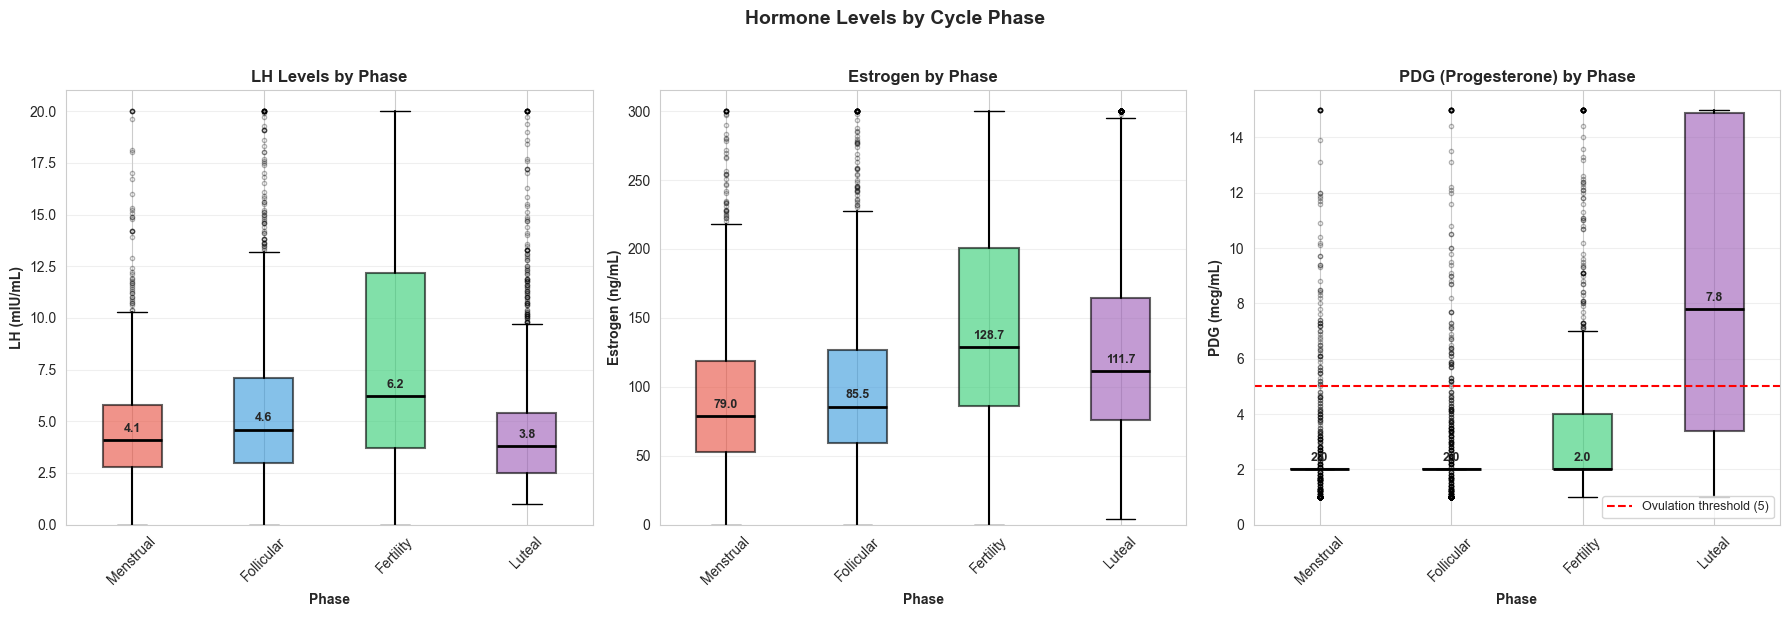

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

phase_order = ['Menstrual', 'Follicular', 'Fertility', 'Luteal']
phase_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

plot_df = hormones.copy()
plot_df['phase'] = pd.Categorical(
    plot_df['phase'], categories=phase_order, ordered=True
)
plot_df = plot_df.sort_values('phase')

# Tighter caps for cleaner visualization
lh_cap = 20        # covers 95%+ of data, LH surge visible
estrogen_cap = 300 # covers most data
pdg_cap = 15       # covers most data, threshold visible

configs = [
    ('lh_imputed',       lh_cap,       'LH Levels by Phase',           'LH (mIU/mL)',       axes[0]),
    ('estrogen_imputed', estrogen_cap, 'Estrogen by Phase',             'Estrogen (ng/mL)',  axes[1]),
    ('pdg_imputed',      pdg_cap,      'PDG (Progesterone) by Phase',   'PDG (mcg/mL)',      axes[2]),
]

for col, cap, title, ylabel, ax in configs:
    
    # Plot per phase with individual colors
    data_by_phase = [
        plot_df[plot_df['phase'] == p][col].clip(upper=cap).dropna()
        for p in phase_order
    ]
    
    bp = ax.boxplot(
        data_by_phase,
        labels=phase_order,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.3),
        whiskerprops=dict(linewidth=1.5),
        boxprops=dict(linewidth=1.5)
    )
    
    # Color each box
    for patch, color in zip(bp['boxes'], phase_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # Add PDG threshold line
    if col == 'pdg_imputed':
        ax.axhline(5, color='red', linestyle='--', 
                   linewidth=1.5, label='Ovulation threshold (5)')
        ax.legend(fontsize=9)
    
    # Annotate medians
    medians = plot_df.groupby('phase')[col].median()
    for i, phase in enumerate(phase_order):
        ax.text(i + 1, medians[phase] + cap*0.02, 
                f'{medians[phase]:.1f}',
                ha='center', fontsize=9, fontweight='bold')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Phase', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(bottom=0)

plt.suptitle('Hormone Levels by Cycle Phase', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hormones_by_phase_final.png', dpi=150, bbox_inches='tight')
print("✓ Saved: hormones_by_phase_final.png")

In [19]:
symptom_cols = [
    'exerciselevel', 'appetite', 'sleepissue', 'foodcravings',
    'indigestion', 'stress', 'bloating', 'moodswing', 'fatigue',
    'headaches', 'sorebreasts', 'cramps'
]

for col in symptom_cols:
    print(f"\n{col}:")
    print(hormones[col].value_counts(dropna=False).head(8))


exerciselevel:
exerciselevel
NaN    4155
3.0    1093
4.0     347
5.0      58
0.0       6
Name: count, dtype: int64

appetite:
appetite
NaN    3238
3.0    1748
4.0     580
5.0      89
0.0       4
Name: count, dtype: int64

sleepissue:
sleepissue
NaN    3097
3.0     688
0.0     662
1.0     649
4.0     362
5.0     201
Name: count, dtype: int64

foodcravings:
foodcravings
NaN    2974
0.0     922
3.0     624
1.0     595
4.0     391
5.0     153
Name: count, dtype: int64

indigestion:
indigestion
NaN    2903
0.0    1183
1.0     724
3.0     528
4.0     238
5.0      83
Name: count, dtype: int64

stress:
stress
NaN    2899
3.0    1050
4.0     610
0.0     436
1.0     370
5.0     290
2.0       4
Name: count, dtype: int64

bloating:
bloating
NaN    2889
0.0    1094
1.0     663
3.0     586
4.0     335
5.0      92
Name: count, dtype: int64

moodswing:
moodswing
NaN    2883
0.0    1032
1.0     780
3.0     612
4.0     268
5.0      84
Name: count, dtype: int64

fatigue:
fatigue
NaN    2880
3.0     936


In [20]:
# Phase-dependent symptoms → impute using phase + user median
phase_dependent = [
    'cramps', 'sorebreasts', 'bloating', 
    'moodswing', 'fatigue', 'headaches', 
    'foodcravings', 'indigestion'
]

# Lifestyle/habit symptoms → impute using user median only
user_dependent = ['exerciselevel', 'stress', 'sleepissue', 'appetite']

# Calculate user median per symptom
user_medians = {}
for col in phase_dependent + user_dependent:
    user_medians[col] = (
        hormones.groupby('id')[col].median()
    )

# Calculate phase median per symptom (for phase-dependent ones)
phase_medians = {}
for col in phase_dependent:
    phase_medians[col] = (
        hormones.groupby('phase')[col].median()
    )

population_medians = {}
for col in phase_dependent + user_dependent:
    population_medians[col] = hormones[col].median()

print("Phase medians for phase-dependent symptoms:")
for col in phase_dependent:
    print(f"\n{col}:")
    print(phase_medians[col].round(2))

Phase medians for phase-dependent symptoms:

cramps:
phase
Fertility     0.0
Follicular    0.0
Luteal        0.0
Menstrual     1.0
Name: cramps, dtype: float64

sorebreasts:
phase
Fertility     0.0
Follicular    0.0
Luteal        0.0
Menstrual     1.0
Name: sorebreasts, dtype: float64

bloating:
phase
Fertility     1.0
Follicular    1.0
Luteal        1.0
Menstrual     3.0
Name: bloating, dtype: float64

moodswing:
phase
Fertility     1.0
Follicular    1.0
Luteal        1.0
Menstrual     1.0
Name: moodswing, dtype: float64

fatigue:
phase
Fertility     3.0
Follicular    3.0
Luteal        3.0
Menstrual     3.0
Name: fatigue, dtype: float64

headaches:
phase
Fertility     1.0
Follicular    1.0
Luteal        1.0
Menstrual     1.0
Name: headaches, dtype: float64

foodcravings:
phase
Fertility     1.0
Follicular    1.0
Luteal        1.0
Menstrual     1.0
Name: foodcravings, dtype: float64

indigestion:
phase
Fertility     1.0
Follicular    1.0
Luteal        1.0
Menstrual     1.0
Name: indige

In [21]:
def impute_symptoms(df):
    df = df.copy()
    
    # Phase-dependent symptoms
    for col in phase_dependent:
        def impute_row(row, col=col):
            if pd.notna(row[col]):
                return row[col]
            # Try user's own median first
            u_median = user_medians[col].get(row['id'], None)
            if pd.notna(u_median):
                return u_median
            # Fall back to phase median
            p_median = phase_medians[col].get(row['phase'], None)
            if pd.notna(p_median):
                return p_median
            # Last resort: population median
            return population_medians[col]
        
        df[f'{col}_imputed'] = df.apply(impute_row, axis=1)
    
    # User/lifestyle dependent symptoms
    for col in user_dependent:
        def impute_row(row, col=col):
            if pd.notna(row[col]):
                return row[col]
            # exerciselevel special case — missing likely means 0
            if col == 'exerciselevel':
                u_median = user_medians[col].get(row['id'], None)
                return u_median if pd.notna(u_median) else 0
            u_median = user_medians[col].get(row['id'], None)
            if pd.notna(u_median):
                return u_median
            return population_medians[col]
        
        df[f'{col}_imputed'] = df.apply(impute_row, axis=1)
    
    return df

hormones = impute_symptoms(hormones)

# Verify
print("\nNulls remaining after imputation:")
imputed_cols = [f'{col}_imputed' for col in phase_dependent + user_dependent]
print(hormones[imputed_cols].isna().sum())


Nulls remaining after imputation:
cramps_imputed           0
sorebreasts_imputed      0
bloating_imputed         0
moodswing_imputed        0
fatigue_imputed          0
headaches_imputed        0
foodcravings_imputed     0
indigestion_imputed      0
exerciselevel_imputed    0
stress_imputed           0
sleepissue_imputed       0
appetite_imputed         0
dtype: int64


In [22]:
print("\nSymptom medians by phase after imputation:")
print(hormones.groupby('phase')[imputed_cols].median().round(2))


Symptom medians by phase after imputation:
            cramps_imputed  sorebreasts_imputed  bloating_imputed  \
phase                                                               
Fertility              0.0                  0.0               1.0   
Follicular             0.0                  0.0               1.0   
Luteal                 0.0                  0.0               1.0   
Menstrual              1.0                  1.0               1.0   

            moodswing_imputed  fatigue_imputed  headaches_imputed  \
phase                                                               
Fertility                 1.0              3.0                1.0   
Follicular                1.0              3.0                1.0   
Luteal                    1.0              3.0                1.0   
Menstrual                 1.0              3.0                1.0   

            foodcravings_imputed  indigestion_imputed  exerciselevel_imputed  \
phase                                         

In [23]:
def impute_symptoms_v2(df):
    df = df.copy()
    
    # Phase-dependent symptoms → phase median FIRST
    for col in phase_dependent:
        def impute_row(row, col=col):
            if pd.notna(row[col]):
                return row[col]
            
            # Try phase median first
            p_median = phase_medians[col].get(row['phase'], None)
            if pd.notna(p_median):
                return p_median
            
            # Fall back to user median
            u_median = user_medians[col].get(row['id'], None)
            if pd.notna(u_median):
                return u_median
            
            return population_medians[col]
        
        df[f'{col}_imputed'] = df.apply(impute_row, axis=1)
    
    # Lifestyle symptoms → user median first (habit-based, not phase-driven)
    for col in user_dependent:
        def impute_row(row, col=col):
            if pd.notna(row[col]):
                return row[col]
            if col == 'exerciselevel':
                u_median = user_medians[col].get(row['id'], None)
                return u_median if pd.notna(u_median) else 0
            u_median = user_medians[col].get(row['id'], None)
            if pd.notna(u_median):
                return u_median
            return population_medians[col]
        
        df[f'{col}_imputed'] = df.apply(impute_row, axis=1)
    
    return df

hormones = impute_symptoms_v2(hormones)

# Check phase medians first before full output
print("Phase medians for key symptoms:")
key_cols = ['cramps_imputed', 'sorebreasts_imputed', 'fatigue_imputed', 'moodswing_imputed']
print(hormones.groupby('phase')[key_cols].median().round(2))

# Also check what raw phase medians look like from original data
print("\nRaw (non-imputed) phase medians:")
for col in phase_dependent:
    print(f"\n{col}:")
    print(hormones.groupby('phase')[col].median().round(2))

Phase medians for key symptoms:
            cramps_imputed  sorebreasts_imputed  fatigue_imputed  \
phase                                                              
Fertility              0.0                  0.0              3.0   
Follicular             0.0                  0.0              3.0   
Luteal                 0.0                  0.0              3.0   
Menstrual              1.0                  1.0              3.0   

            moodswing_imputed  
phase                          
Fertility                 1.0  
Follicular                1.0  
Luteal                    1.0  
Menstrual                 1.0  

Raw (non-imputed) phase medians:

cramps:
phase
Fertility     0.0
Follicular    0.0
Luteal        0.0
Menstrual     1.0
Name: cramps, dtype: float64

sorebreasts:
phase
Fertility     0.0
Follicular    0.0
Luteal        0.0
Menstrual     1.0
Name: sorebreasts, dtype: float64

bloating:
phase
Fertility     1.0
Follicular    1.0
Luteal        1.0
Menstrual     3.0
Na

In [24]:
# Symptom imputation is done — accept phase-based where signal exists
# cramps, sorebreasts, bloating → phase signal exists ✅
# everything else → population/user median is the honest imputation ✅

# Final null check
imputed_cols = [f'{col}_imputed' for col in phase_dependent + user_dependent]
print("Final null counts:")
print(hormones[imputed_cols].isna().sum())

# Document this finding
print("""
NOTE FOR YOUR REPORT:
Symptom imputation used phase-based medians where phase signal existed 
(cramps, sorebreasts, bloating show Menstrual phase elevation).
Remaining symptoms showed no significant phase variation in observed data,
so user/population medians were used. High missingness (47-73%) means 
symptom analysis should be interpreted cautiously.
""")

Final null counts:
cramps_imputed           0
sorebreasts_imputed      0
bloating_imputed         0
moodswing_imputed        0
fatigue_imputed          0
headaches_imputed        0
foodcravings_imputed     0
indigestion_imputed      0
exerciselevel_imputed    0
stress_imputed           0
sleepissue_imputed       0
appetite_imputed         0
dtype: int64

NOTE FOR YOUR REPORT:
Symptom imputation used phase-based medians where phase signal existed 
(cramps, sorebreasts, bloating show Menstrual phase elevation).
Remaining symptoms showed no significant phase variation in observed data,
so user/population medians were used. High missingness (47-73%) means 
symptom analysis should be interpreted cautiously.




SYMPTOM CORRELATION ANALYSIS

✓ Saved: symptom_correlation.png

Strongest Symptom Correlations:
symptom_1    symptom_2  correlation
   cramps  sorebreasts     0.635416
  fatigue       stress     0.548610
 bloating foodcravings     0.535570
moodswing foodcravings     0.483238
moodswing     bloating     0.476901


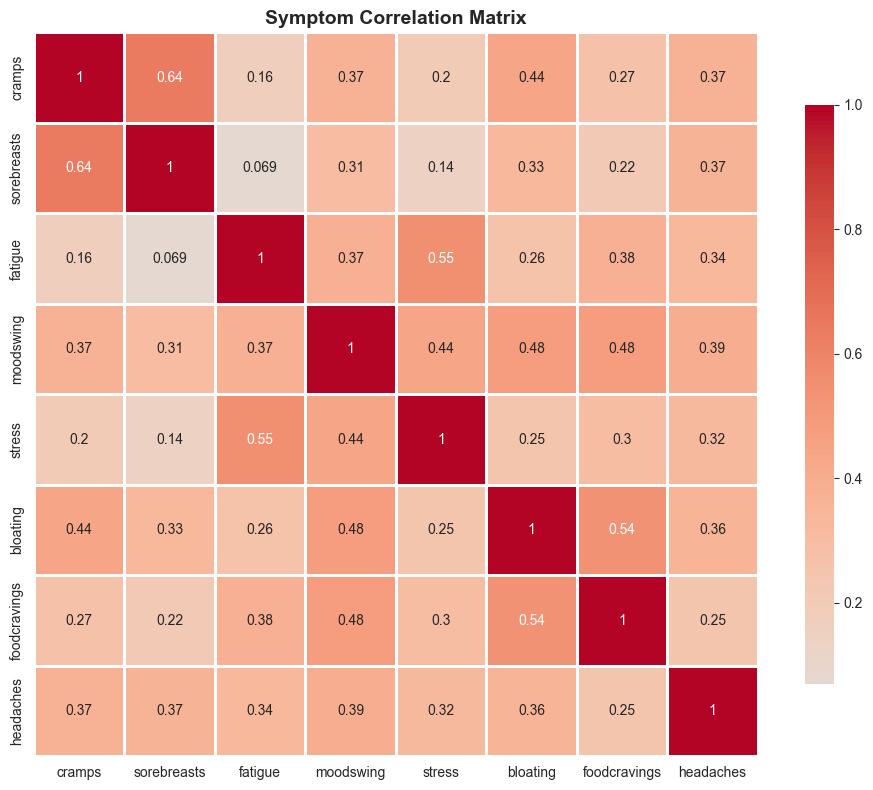

In [25]:
# ============================================================================
# SECTION 5: SYMPTOM CORRELATION ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("SYMPTOM CORRELATION ANALYSIS")
print("="*70)

# Select symptom columns
symptom_cols = ['cramps', 'sorebreasts', 'fatigue', 'moodswing', 'stress', 
                'bloating', 'foodcravings', 'headaches']
available_symptoms = [col for col in symptom_cols if col in hormones.columns]

if len(available_symptoms) > 3:
    # Correlation matrix
    corr_matrix = hormones[available_symptoms].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Symptom Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('symptom_correlation.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: symptom_correlation.png")
    
    # Find strongest correlations
    print("\nStrongest Symptom Correlations:")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append({
                'symptom_1': corr_matrix.columns[i],
                'symptom_2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })
    
    corr_df = pd.DataFrame(corr_pairs).sort_values('correlation', ascending=False)
    print(corr_df.head(5).to_string(index=False))


DATA QUALITY REPORT

Missing Data Percentage:
  exerciselevel: 73.4%
  pdg: 67.1%
  appetite: 57.2%
  sleepissue: 54.7%
  foodcravings: 52.6%
  indigestion: 51.3%
  stress: 51.2%
  bloating: 51.1%
  moodswing: 50.9%
  fatigue: 50.9%
  headaches: 50.1%
  sorebreasts: 47.4%
  cramps: 46.4%
  flow_volume_numeric: 43.6%
  flow_volume: 43.6%
  flow_color: 43.6%
  estrogen_clean: 6.6%
  estrogen: 5.7%
  lh: 5.7%

✓ Saved: data_quality.png

Participant Tracking Quality:
  Average days tracked: 134.7
  Average completeness: 61.6%
  Participants with >80% complete data: 22

EXPLORATORY ANALYSIS COMPLETE!

Generated visualizations:
  1. participant_cycle_visualization.png - Single participant cycle
  2. cycle_analysis.png - Cycle length distributions
  3. hormones_by_phase.png - Hormone patterns by phase
  4. symptom_correlation.png - Symptom relationships
  5. data_quality.png - Missing data analysis

Next steps:
  → Review visualizations to understand patterns
  → Run mcphases_cycle_predictio

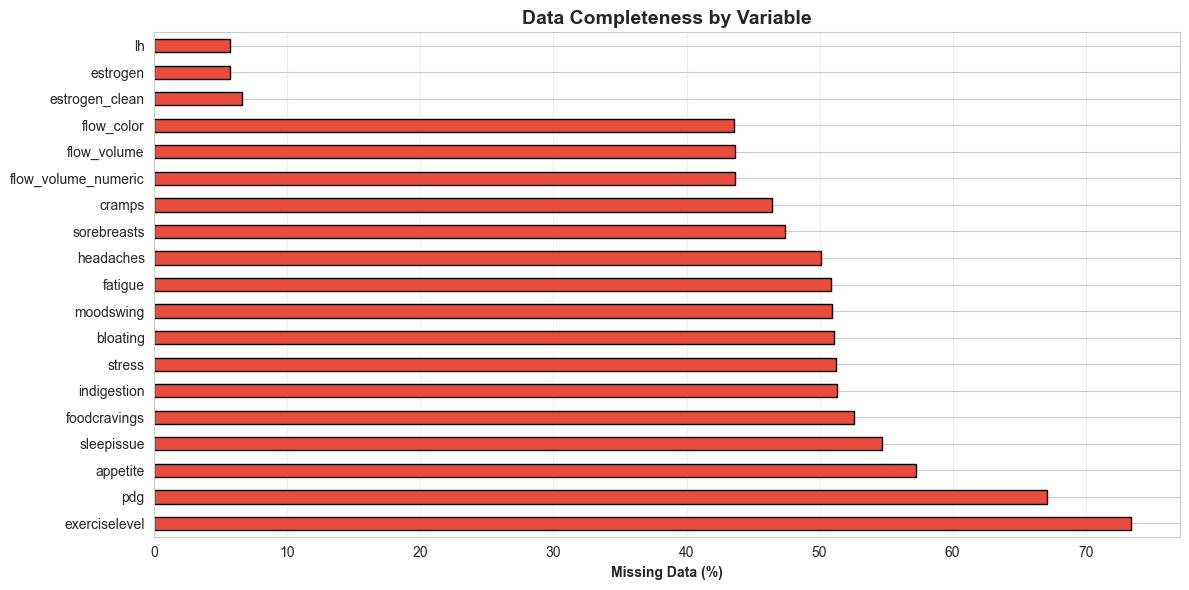

In [26]:
# ============================================================================
# SECTION 6: DATA QUALITY REPORT
# ============================================================================

print("\n" + "="*70)
print("DATA QUALITY REPORT")
print("="*70)

# Missing data analysis
missing_data = hormones.isnull().sum() / len(hormones) * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    print("\nMissing Data Percentage:")
    for col, pct in missing_data.items():
        print(f"  {col}: {pct:.1f}%")
    
    # Visualize
    plt.figure(figsize=(12, 6))
    missing_data.plot(kind='barh', color='#e74c3c', edgecolor='black')
    plt.xlabel('Missing Data (%)', fontweight='bold')
    plt.title('Data Completeness by Variable', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('data_quality.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: data_quality.png")

# Participant tracking consistency
participant_days = hormones.groupby('id')['day_in_study'].agg(['count', 'min', 'max'])
participant_days['span'] = participant_days['max'] - participant_days['min'] + 1
participant_days['completeness'] = participant_days['count'] / participant_days['span'] * 100

print(f"\nParticipant Tracking Quality:")
print(f"  Average days tracked: {participant_days['count'].mean():.1f}")
print(f"  Average completeness: {participant_days['completeness'].mean():.1f}%")
print(f"  Participants with >80% complete data: {(participant_days['completeness'] > 80).sum()}")

print("\n" + "="*70)
print("EXPLORATORY ANALYSIS COMPLETE!")
print("="*70)
print("\nGenerated visualizations:")
print("  1. participant_cycle_visualization.png - Single participant cycle")
print("  2. cycle_analysis.png - Cycle length distributions")
print("  3. hormones_by_phase.png - Hormone patterns by phase")
print("  4. symptom_correlation.png - Symptom relationships")
print("  5. data_quality.png - Missing data analysis")
print("\nNext steps:")
print("  → Review visualizations to understand patterns")
print("  → Run mcphases_cycle_prediction.py for modeling")
print("  → Read GETTING_STARTED.md for detailed guidance")

In [27]:
hormones

,id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,flow_color,...,bloating_imputed,moodswing_imputed,fatigue_imputed,headaches_imputed,foodcravings_imputed,indigestion_imputed,exerciselevel_imputed,stress_imputed,sleepissue_imputed,appetite_imputed
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Not at all,Not at all,...,1.0,1.0,4.0,4.0,1.0,1.0,3.0,3.0,1.0,3.0
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Not at all,Not at all,...,1.0,1.0,4.0,5.0,1.0,1.0,3.0,3.0,5.0,3.0
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Not at all,Not at all,...,1.0,1.0,5.0,4.0,1.0,1.0,3.0,1.0,5.0,3.0
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Not at all,Not at all,...,1.0,1.0,4.0,1.0,1.0,1.0,3.0,1.0,5.0,3.0
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Not at all,Not at all,...,1.0,1.0,4.0,1.0,1.0,1.0,3.0,1.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5654,50,2024,False,947,Luteal,4.6,70.7,2.8,NaN,NaN,...,1.0,1.0,3.0,1.0,1.0,1.0,3.0,3.0,3.0,4.0
5655,50,2024,False,948,Luteal,5.8,87.0,7.0,NaN,NaN,...,1.0,1.0,3.0,1.0,1.0,1.0,3.0,3.0,3.0,4.0
5656,50,2024,False,949,Luteal,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,3.0,1.0,1.0,1.0,3.0,3.0,3.0,4.0
5657,50,2024,False,950,Menstrual,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,3.0,1.0,1.0,1.0,3.0,3.0,3.0,4.0


In [28]:
hormones.columns

Index(['id', 'study_interval', 'is_weekend', 'day_in_study', 'phase', 'lh',
       'estrogen', 'pdg', 'flow_volume', 'flow_color', 'appetite',
       'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue',
       'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion',
       'bloating', 'is_bleeding', 'flow_grp_Abnormal', 'flow_grp_Fresh',
       'flow_grp_No Flow', 'flow_grp_Old', 'flow_volume_numeric',
       'period_start', 'period_id', 'day_in_period', 'flow_volume_imputed',
       'lh_surge', 'pdg_imputed', 'estrogen_capped_flag', 'estrogen_clean',
       'estrogen_imputed', 'high_estrogen_flag', 'lh_imputed',
       'cramps_imputed', 'sorebreasts_imputed', 'bloating_imputed',
       'moodswing_imputed', 'fatigue_imputed', 'headaches_imputed',
       'foodcravings_imputed', 'indigestion_imputed', 'exerciselevel_imputed',
       'stress_imputed', 'sleepissue_imputed', 'appetite_imputed'],
      dtype='object')

In [29]:
phase_order = {
    'Menstrual':   1,
    'Follicular':  2,
    'Fertility':   3,
    'Luteal':      4
}
hormones['phase'] = hormones['phase'].map(phase_order)
print(hormones['phase'].unique())  # should show [1 2 3 4]

[2 3 4 1]


In [30]:
hormones.to_csv('hormones_clean.csv', index=False)